## Import data and library

In [1]:
from sklearn.model_selection import train_test_split, KFold
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline  
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, LogisticRegression
from sklearn.preprocessing import MinMaxScaler, StandardScaler,RobustScaler,OneHotEncoder, OrdinalEncoder,label_binarize
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error,accuracy_score, classification_report, confusion_matrix,roc_curve, auc
from sklearn.ensemble import RandomForestClassifier

import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
plt.style.use('bmh')

from joblib import load
from joblib import dump

In [2]:
df = pd.read_csv('df_model.csv')
df = df.drop('Unnamed: 0', axis=1)

In [3]:
Model0 = load('model_linear_reg.joblib')
Model1 = load('model_Ridge.joblib')
Model2 = load('model_Lasso.joblib')
Model3 = load('model_DecisionTreeRegressor.joblib')
Model4 = load('model_LogisticRegression.joblib')
Model5 = load('RandomForestClassifier.joblib')

In [4]:
danceability_cat = pd.cut(df['danceability'],
                         bins=[-1, 0.3, 0.6,11], 
                        labels=['low', 'medium', 'high'])

In [5]:
train_set, test_set, danceability_cat_train, danceability_cat_test = train_test_split(
    df,  
    danceability_cat,
    test_size=0.2, 
    shuffle=True,  
    random_state=2025,  
    stratify=danceability_cat  )

In [6]:
df_class_y_train = danceability_cat_train
df_class_x_train = train_set.drop(labels=['danceability', 'acousticness'], axis=1)
df_class_y_test = danceability_cat_test 
df_class_x_test = test_set.drop(labels=['danceability', 'acousticness'], axis=1)

In [7]:
df_class_x_test

,loudness,tempo,energy
1183,-5.005,121.977,0.836
465,-7.647,119.948,0.545
3941,-8.597,104.000,0.603
208,-4.883,153.067,0.749
1943,-11.800,138.008,0.705
...,...,...,...
2460,-3.169,114.992,0.915
5299,-10.877,110.039,0.658
706,-3.516,120.029,0.945
2303,-6.889,78.964,0.586


In [8]:
df_reg_x_test =test_set.drop(labels=['energy','danceability'], axis=1)
df_reg_x_train = train_set.drop(labels=['energy','danceability'], axis=1)
df_reg_y_test = test_set['energy'].copy()
df_reg_y_train = train_set['energy'].copy()

In [9]:
df_class_x_test

,loudness,tempo,energy
1183,-5.005,121.977,0.836
465,-7.647,119.948,0.545
3941,-8.597,104.000,0.603
208,-4.883,153.067,0.749
1943,-11.800,138.008,0.705
...,...,...,...
2460,-3.169,114.992,0.915
5299,-10.877,110.039,0.658
706,-3.516,120.029,0.945
2303,-6.889,78.964,0.586


## Regression model

In [10]:
predictions0 = Model0.predict(df_reg_x_test)
predictions1 = Model1.predict(df_reg_x_test)
predictions2 = Model2.predict(df_reg_x_test)
predictions3 = Model3.predict(df_reg_x_test)

In [11]:
regression_results = []

In [12]:
for i, (model, predictions) in enumerate(zip(
    [Model0, Model1, Model2, Model3],
    [predictions0, predictions1, predictions2, predictions3]
)):
    model_name = ["Linear Regression", "Ridge Regression", "Lasso Regression", "Decision Tree"][i]
    r2 = r2_score(df_reg_y_test, predictions)
    mae = mean_absolute_error(df_reg_y_test, predictions)
    mse = mean_squared_error(df_reg_y_test, predictions)
    rmse = np.sqrt(mse)
    
    regression_results.append({
        "Model": model_name,
        "R²": r2,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse
    })
    print(f"\n{model_name}:")
    print(f"R²: {r2:.4f}")
    print(f"MAE: {mae:.4f}")
    print(f"MSE: {mse:.4f}")
    print(f"RMSE: {rmse:.4f}")



Linear Regression:
R²: 0.6336
MAE: 0.0931
MSE: 0.0131
RMSE: 0.1146

Ridge Regression:
R²: 0.6336
MAE: 0.0931
MSE: 0.0131
RMSE: 0.1146

Lasso Regression:
R²: 0.6336
MAE: 0.0931
MSE: 0.0131
RMSE: 0.1146

Decision Tree:
R²: 0.9632
MAE: 0.0068
MSE: 0.0013
RMSE: 0.0363


## Classification model

In [13]:
df_class_x_test  = df_class_x_test[['loudness','energy','tempo']]

In [14]:
predictions4 = Model4.predict(df_class_x_test)
predictions5 = Model5.predict(df_class_x_test)

In [15]:
prob_predictions4 = Model4.predict_proba(df_class_x_test)
prob_predictions5 = Model5.predict_proba(df_class_x_test)

In [16]:
models = ["Logistic", "RandomForest"]
predictions = [predictions4, predictions5]
prob_preds = [prob_predictions4, prob_predictions5]

In [17]:
for i, model_name in enumerate(models):
    accuracy = accuracy_score(df_class_y_test, predictions[i])
    print(f"{model_name} Accuracy: {accuracy:.4f}")

Logistic Accuracy: 0.6254
RandomForest Accuracy: 0.6398


In [18]:
for i, model_name in enumerate(models):
    print(f"\n{model_name} Classification Report:")
    print(classification_report(df_class_y_test, predictions[i]))


Logistic Classification Report:
              precision    recall  f1-score   support

        high       0.62      0.98      0.76       686
         low       0.00      0.00      0.00         2
      medium       0.65      0.06      0.11       428

    accuracy                           0.63      1116
   macro avg       0.42      0.35      0.29      1116
weighted avg       0.63      0.63      0.51      1116


RandomForest Classification Report:
              precision    recall  f1-score   support

        high       0.64      0.94      0.76       686
         low       0.00      0.00      0.00         2
      medium       0.63      0.16      0.25       428

    accuracy                           0.64      1116
   macro avg       0.42      0.37      0.34      1116
weighted avg       0.64      0.64      0.57      1116



c:\Users\champ\miniconda3\envs\aml\lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\champ\miniconda3\envs\aml\lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\champ\miniconda3\envs\aml\lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\c

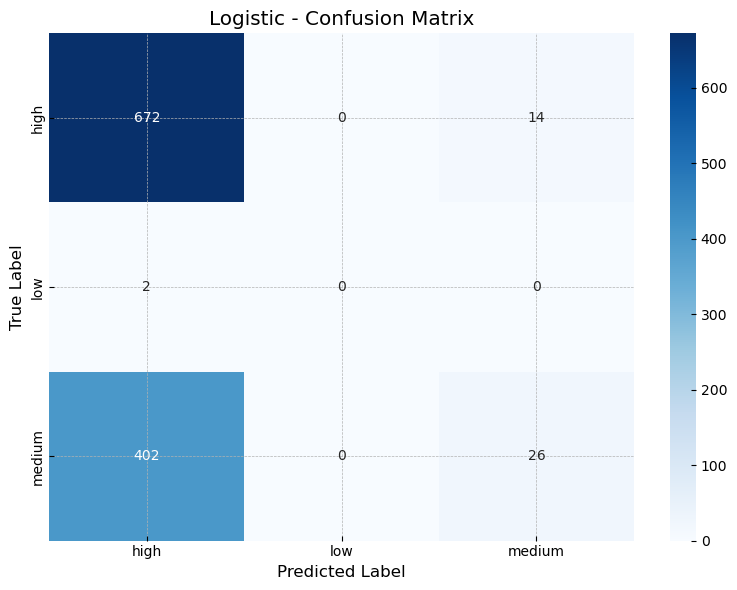

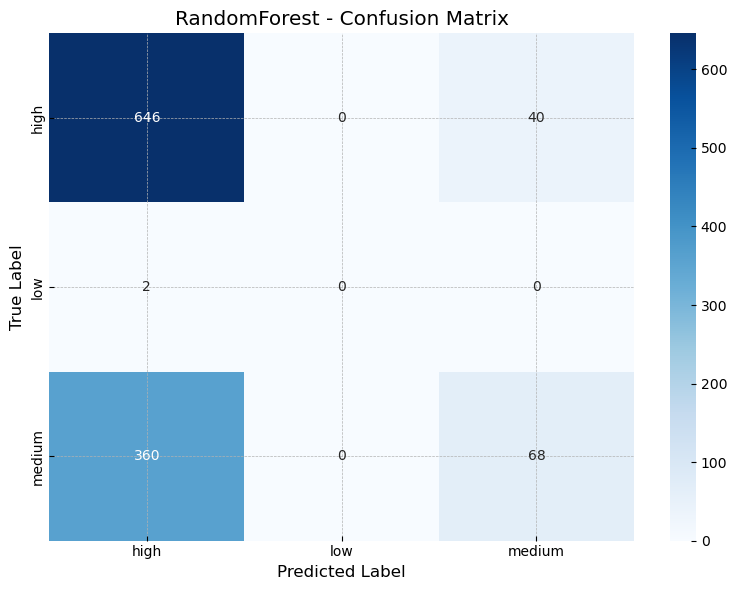

In [22]:
for i, model_name in enumerate(models):
    cm = confusion_matrix(df_class_y_test, predictions[i])
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=np.unique(df_class_y_test),
                yticklabels=np.unique(df_class_y_test))
    plt.title(f'{model_name} - Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()

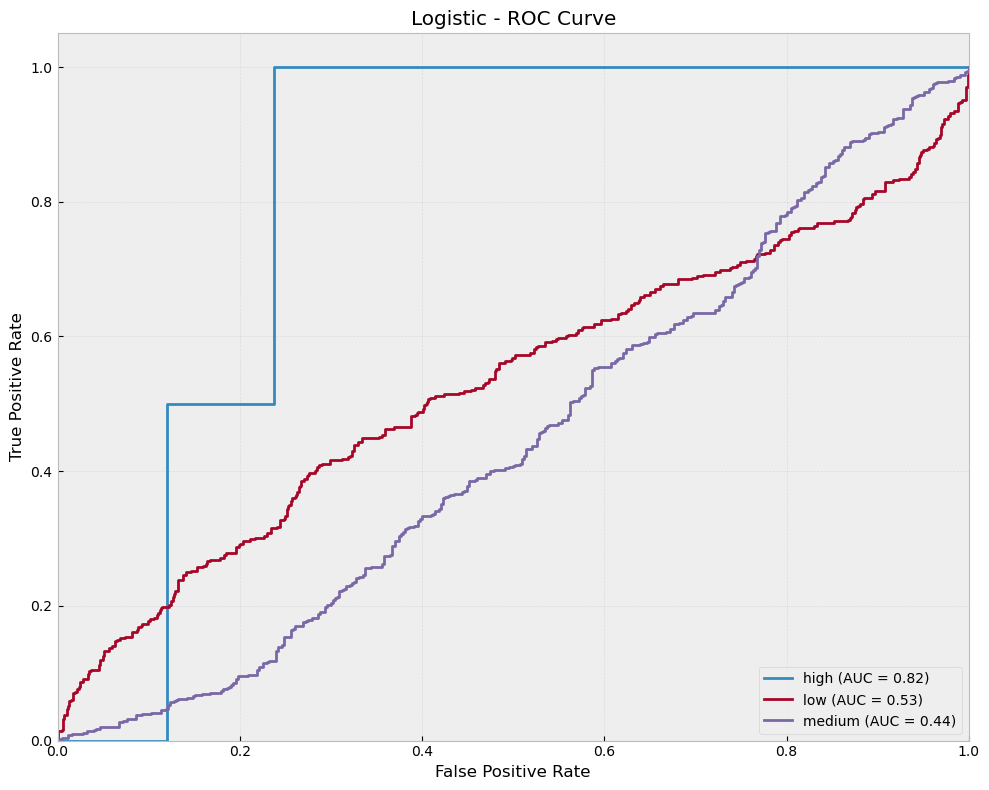

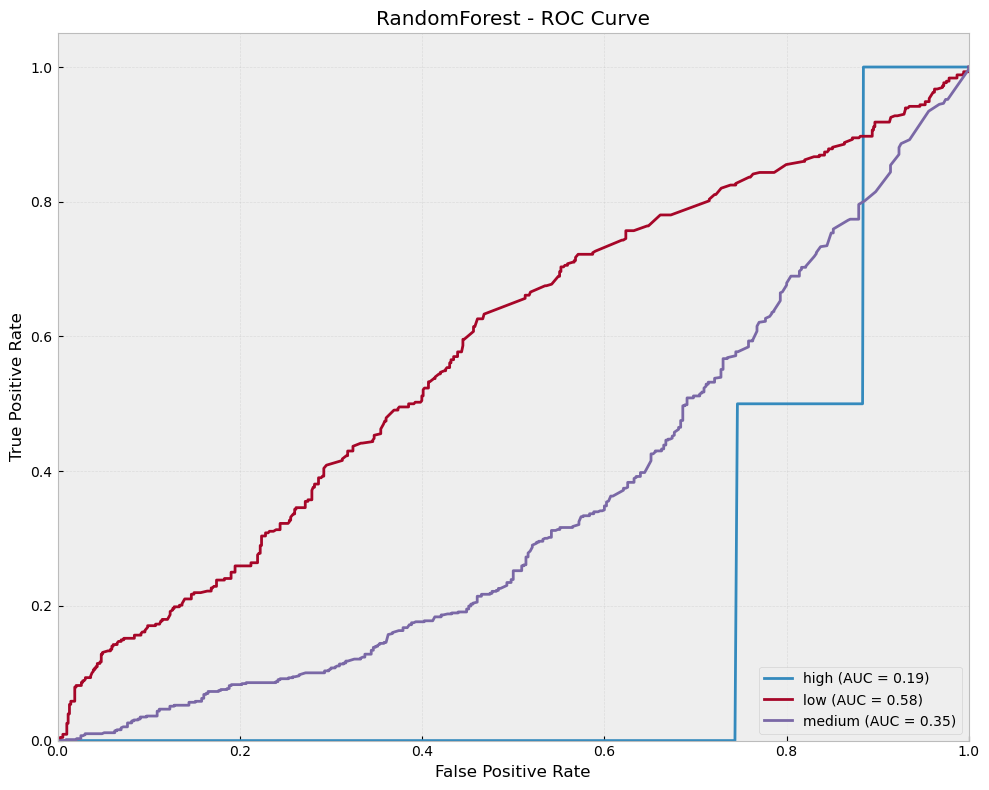

In [23]:
y_test_bin = pd.get_dummies(df_class_y_test)
classes = np.unique(df_class_y_test)

for i, model_name in enumerate(models):
    plt.figure(figsize=(10, 8))
    for j, cls in enumerate(classes):
        fpr, tpr, _ = roc_curve(y_test_bin.iloc[:, j], prob_preds[i][:, j])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, 
                 label=f'{cls} (AUC = {roc_auc:.2f})')
    
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'{model_name} - ROC Curve')
    plt.legend(loc="lower right")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()